#### Importar las librerías para desarrollar el proyecto

In [1]:
#Importar las librerías

# Análisis de información
import pandas as pd

# Visualización de información
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#### Importar archivo Excel desde el almacenamiento local

In [2]:
#Importar la base de datos desde un archivo Excel

ruta = r"C:\Users\Jorge\Downloads\registros_finales_2026 (1).xlsx"

try:
    database = pd.read_excel(ruta, sheet_name="Atenciones_Marzo_Junio_2026")
    print(f'La base de datos ha sido cargada exitosamente')
    
except Exception as e: 
    print('Error al cargar la base de datos.')
    print(f'Error: {e}')

La base de datos ha sido cargada exitosamente


In [3]:
# Análisis exploratorio de datos (EDA)

print("La base de datos 'Atenciones Marzo-Junio' tiene la siguiente información:")
print()
print(database.info())
print()
print("====================================================================================")
print("Dimensiones de la base de datos:")
print()
print(f"La base tiene {database.shape[0]} filas y {database.shape[1]} columnas")
print()
print("====================================================================================")
print("La base de datos tiene las siguiente estadísticas:")
print()
print(database.describe())
print()
print("====================================================================================")
print("La base de datos tiene los siguientes datos ausentes por columna:")
print()
print(database.isnull().sum())
print()
print("====================================================================================")
print("La base de datos tiene los siguientes porcentajes de datos ausentes por columna:")
print()
# Calcular el porcentaje de datos faltantes por columna
for columna in database.columns:
    no_data = database[columna].isnull().sum()
    no_data_porc = (no_data / len(database)) * 100
    print(f"El porcentaje de datos ausentes para la columna {columna} es: {no_data_porc:.2f}%")
    print()

La base de datos 'Atenciones Marzo-Junio' tiene la siguiente información:

<class 'pandas.DataFrame'>
RangeIndex: 3561 entries, 0 to 3560
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Fecha          3561 non-null   datetime64[us]
 1   Hora           3561 non-null   int64         
 2   Subido         3561 non-null   bool          
 3   Folio          3561 non-null   object        
 4   Observaciones  3383 non-null   str           
 5   Actividad      3129 non-null   str           
 6   Sexo           2879 non-null   str           
dtypes: bool(1), datetime64[us](1), int64(1), object(1), str(3)
memory usage: 170.5+ KB
None

Dimensiones de la base de datos:

La base tiene 3561 filas y 7 columnas

La base de datos tiene las siguiente estadísticas:

                            Fecha         Hora
count                        3561  3561.000000
mean   2026-05-05 09:57:16.225779     2.712721
min        

#### Conversión de tipo de datos

In [4]:
# Convertir la columna "Fecha" al tipo datetime

database["Fecha"] = pd.to_datetime(database["Fecha"], format="%d/%m/%y")
print(f"La columna 'Fecha' es del tipo: {database['Fecha'].dtype}")

La columna 'Fecha' es del tipo: datetime64[us]


#### Observación de datos

In [5]:
# Histórico de atenciones por día
atenciones_diarias = database.groupby("Fecha").size().reset_index(drop=False)
atenciones_diarias= atenciones_diarias.rename(columns={
    'Fecha' : 'Fecha', 
     0 : 'Total'
    })

atenciones_diarias_df = pd.DataFrame(atenciones_diarias)

print(atenciones_diarias_df)

        Fecha  Total
0  2026-03-19     32
1  2026-03-20     46
2  2026-03-21     30
3  2026-03-23     72
4  2026-03-24     30
..        ...    ...
66 2026-06-12     20
67 2026-06-13     34
68 2026-06-15     99
69 2026-06-16     75
70 2026-06-17     74

[71 rows x 2 columns]


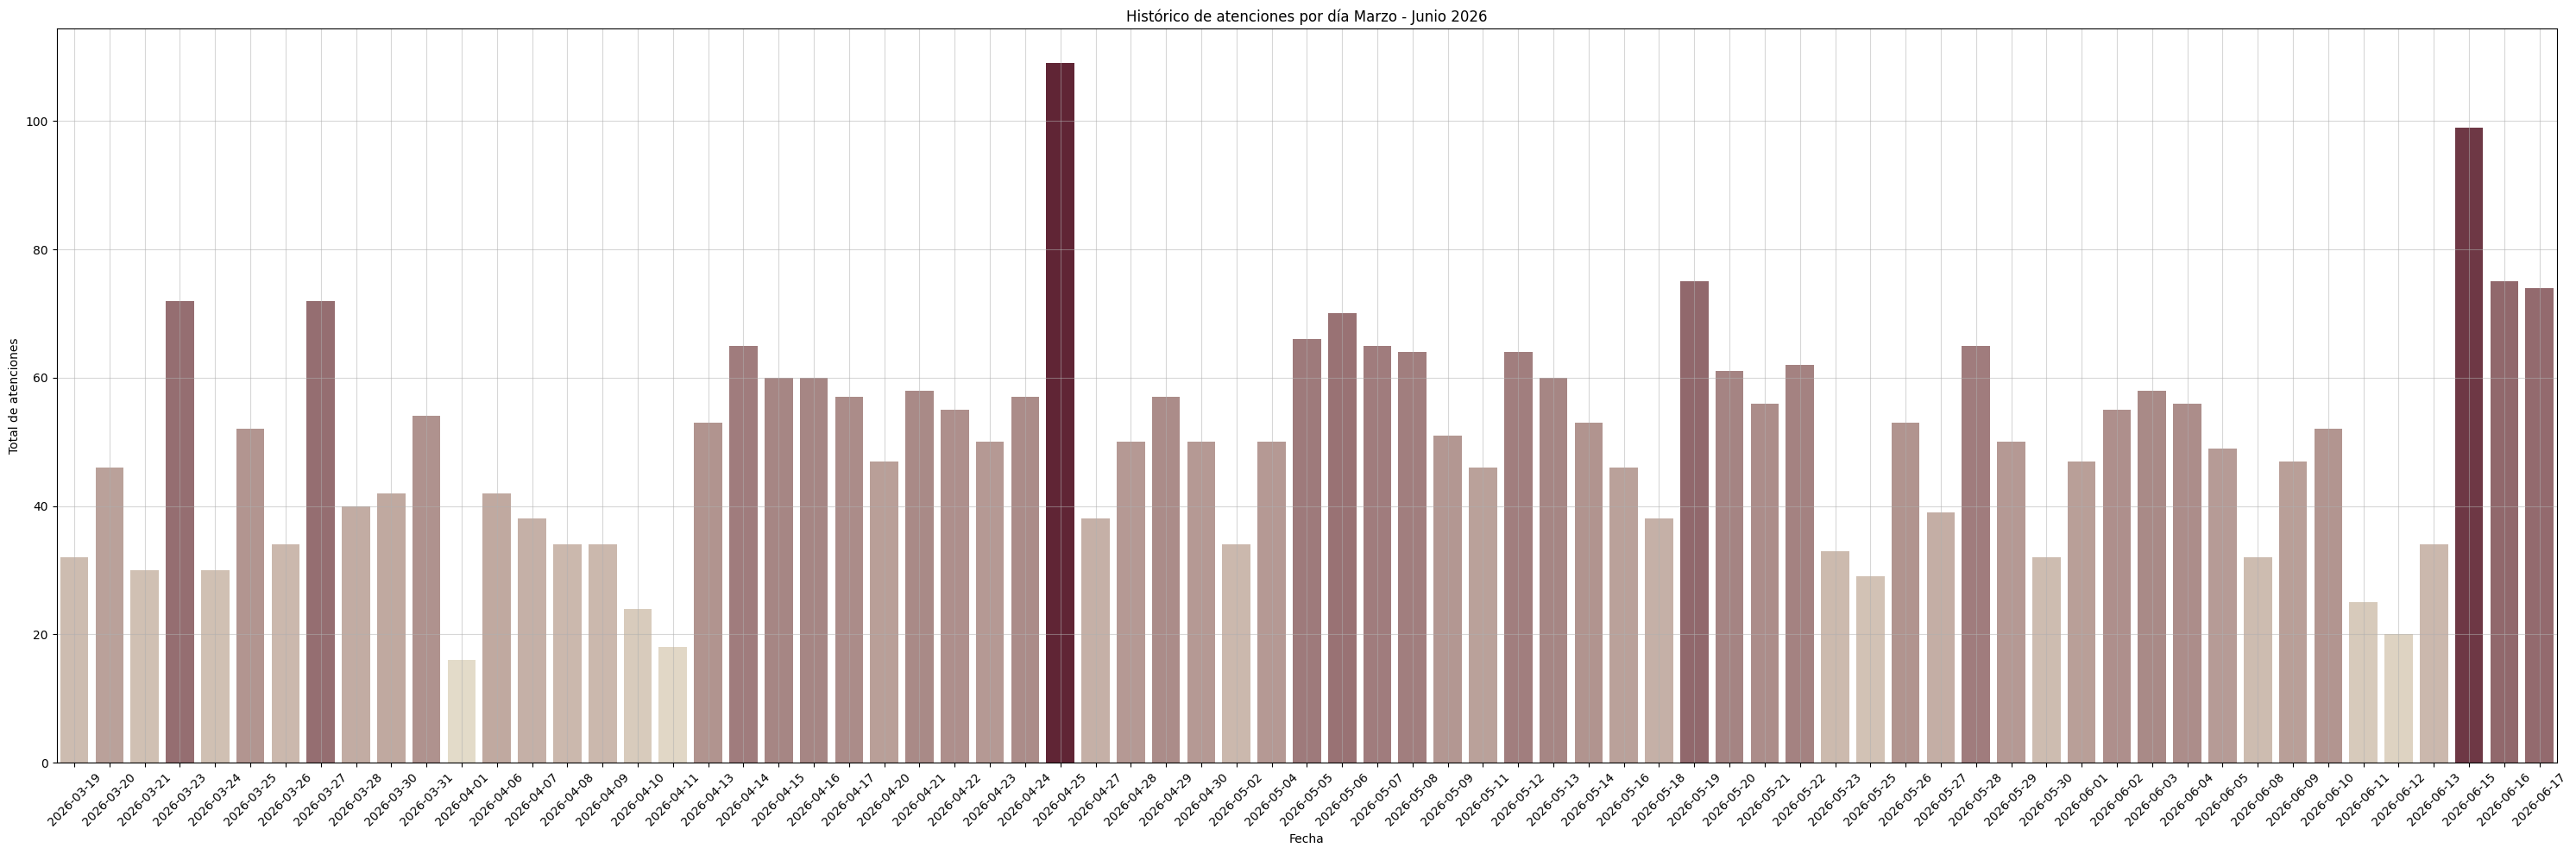

In [6]:
# Histórico de atenciones por día
plt.figure(figsize=(30,10))
sns.barplot(x="Fecha", y="Total", data=atenciones_diarias_df, palette="blend:#E8DCC4,#6A1B31", hue="Total", legend=False)
plt.title("Histórico de atenciones por día Marzo - Junio 2026")
plt.xlabel("Fecha")
plt.ylabel("Total de atenciones")
plt.grid(True, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

